<a href="https://colab.research.google.com/github/bkekgathetse/setswana-offensive-977/blob/main/notebooks/Afro_Xmlr_80_20_CV_TagFreeTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Fine-Tuning Afro-XLM-RoBERTa with 5-Fold CV on 80% Train Set + Final Test on 20% Holdout
# Dataset: 477 Offensive, 500 Non-Offensive Samples

!pip install transformers datasets torch scikit-learn

import os
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score, matthews_corrcoef
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset
from torch.nn import CrossEntropyLoss

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

model_name = 'Davlan/afro-xlmr-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.add_special_tokens({'additional_special_tokens': ['<TRIGGER>', '</TRIGGER>']})

# Assuming 'tokenizer' (e.g., from XLM-R) is loaded and the special tokens are added:
# tokenizer.add_special_tokens({'additional_special_tokens': ['<TRIGGER>', '</TRIGGER>']})

# Get the unique token IDs for the special tokens
TRIGGER_START_ID = tokenizer.convert_tokens_to_ids('<TRIGGER>')
TRIGGER_END_ID = tokenizer.convert_tokens_to_ids('</TRIGGER>')

# Load the dataset, 80% training set with <TRIGGER> (train_df), and 20% testing tag/triggers free (test_df)
train_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/training_data.csv')
test_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/testing_data2.csv')
train_df['TEXT'] = train_df['TEXT'].astype(str)
test_df['TEXT'] = test_df['TEXT'].astype(str)

# Define label_map globally so it's accessible by tokenize_batch_with_indices and other functions
label_map = {'Non-offensive': 0, 'Offensive': 1}

def tokenize_batch_with_indices(batch):
    """
    Tokenizes the input text and finds the index of the <TRIGGER> and </TRIGGER> tokens.
    """
    # Standard tokenization (adjust max_length as needed)
    tokenized = tokenizer(
        batch['TEXT'],
        padding='max_length',
        truncation=True,
        max_length=128,
        # Do not return tensors yet; keep as lists for easy index search
    )

    trigger_start_indices = []
    trigger_end_indices = []

    for ids in tokenized['input_ids']:
        # Find the index of the first occurrence of the start and end tokens
        start_idx = ids.index(TRIGGER_START_ID) if TRIGGER_START_ID in ids else -1
        end_idx = ids.index(TRIGGER_END_ID) if TRIGGER_END_ID in ids else -1

        trigger_start_indices.append(start_idx)
        trigger_end_indices.append(end_idx)

    # Add the custom indices to the dataset structure
    tokenized['trigger_start_index'] = trigger_start_indices
    tokenized['trigger_end_index'] = trigger_end_indices

    # Map the classification label (e.g., Offensive: 1, Non-Offensive: 0)
    tokenized['labels'] = [label_map[target] for target in batch['TARGET']]

    return tokenized

# NOTE: You MUST ensure your Dataset.map() call uses this function:
# tokenized_dataset = raw_dataset.map(tokenize_batch_with_indices, batched=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None, labels=[0, 1])
    return {
        'accuracy': accuracy_score(labels, preds),
        'mcc': matthews_corrcoef(labels, preds),
        'roc_auc': roc_auc_score(labels, torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()),
        'f1_macro': f1.mean(),
        'recall_1': recall[1]
    }

def compute_weighted_loss(model, inputs, return_outputs=False):
    labels = inputs.pop('labels')
    outputs = model(**inputs)
    loss_fct = CrossEntropyLoss(weight=torch.tensor([1.0, 2.0]).to(model.device))
    loss = loss_fct(outputs.logits.view(-1, 2), labels.view(-1))
    return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir='/content/drive/My Drive/Colab Notebooks/AfroXLMR-80-20-tagfreeTest',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    learning_rate=1e-5,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    save_strategy='no',
    eval_strategy='epoch',
    metric_for_best_model='recall_1',
    greater_is_better=True,
    load_best_model_at_end=False
)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
best_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(train_df['TEXT'], train_df['TARGET'])):
    print(f'\n=== Fold {fold + 1}/5 ===')
    train_fold = train_df.iloc[train_idx]
    val_fold = train_df.iloc[val_idx]

    train_dataset = Dataset.from_pandas(train_fold).map(tokenize_batch_with_indices, batched=True)
    val_dataset = Dataset.from_pandas(val_fold).map(tokenize_batch_with_indices, batched=True)
    train_dataset = train_dataset.rename_column('TARGET', 'label')
    val_dataset = val_dataset.rename_column('TARGET', 'label')

    # Removed redundant label_mapping definition from here
    train_dataset = train_dataset.map(lambda examples: {'label': [label_map[x] for x in examples['label']]}, batched=True)
    val_dataset = val_dataset.map(lambda examples: {'label': [label_map[x] for x in examples['label']]}, batched=True)

    train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, ignore_mismatched_sizes=True)
    model.resize_token_embeddings(len(tokenizer))

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
    )
    trainer.loss_function = compute_weighted_loss
    trainer.train()
    metrics = trainer.evaluate()
    fold_results.append(metrics)
    best_models.append(model)
    print(metrics)

best_fold_index = np.argmax([r['eval_recall_1'] for r in fold_results])
best_model = best_models[best_fold_index]
print(f'\nBest Fold: Fold {best_fold_index + 1}')

# test_dataset = Dataset.from_pandas(test_df).map(tokenize_batch, batched=True)
# test_dataset = test_dataset.rename_column('TARGET LABEL', 'label')
# test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

test_dataset = Dataset.from_pandas(test_df).map(tokenize_batch_with_indices, batched=True)
test_dataset = test_dataset.rename_column('TARGET', 'label')

# Apply label_map to test_dataset before setting format
test_dataset = test_dataset.map(lambda examples: {'label': [label_map[x] for x in examples['label']]}, batched=True) # Apply label mapping to the test dataset
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

test_trainer = Trainer(
    model=best_model,
    args=TrainingArguments(output_dir='./tmp-test-jw300', per_device_eval_batch_size=64),
    compute_metrics=compute_metrics
)
test_metrics = test_trainer.evaluate(test_dataset)
print('\n=== Test Set Metrics ===')
print(test_metrics)

test_trainer = Trainer(
    model=best_model,
    args=TrainingArguments(output_dir='./tmp-test-afroxlmr', per_device_eval_batch_size=64),
    compute_metrics=compute_metrics
)
test_metrics = test_trainer.evaluate(test_dataset)
print('\n=== Test Set Metrics ===')
print(test_metrics)

save_dir = '/content/drive/My Drive/Colab Notebooks/AfroXLMR-best-fold-model'
best_model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Best performing model saved to: {save_dir}")

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

{'eval_loss': 0.021017737686634064, 'eval_accuracy': 0.9935897435897436, 'eval_mcc': 0.9872606263311616, 'eval_roc_auc': 1.0, 'eval_f1_macro': 0.9935894801725909, 'eval_recall_1': 0.9871794871794872, 'eval_runtime': 0.9703, 'eval_samples_per_second': 160.778, 'eval_steps_per_second': 3.092, 'epoch': 5.0}

Best Fold: Fold 5


Map:   0%|          | 0/196 [00:00<?, ? examples/s]

Map:   0%|          | 0/196 [00:00<?, ? examples/s]


=== Test Set Metrics ===
{'eval_loss': 2.2872495651245117, 'eval_model_preparation_time': 0.0026, 'eval_accuracy': 0.5459183673469388, 'eval_mcc': 0.07771670373790977, 'eval_roc_auc': 0.6889937106918239, 'eval_f1_macro': 0.3631484794275492, 'eval_recall_1': 0.011111111111111112, 'eval_runtime': 1.208, 'eval_samples_per_second': 162.258, 'eval_steps_per_second': 3.311}



=== Test Set Metrics ===
{'eval_loss': 2.2872495651245117, 'eval_model_preparation_time': 0.0026, 'eval_accuracy': 0.5459183673469388, 'eval_mcc': 0.07771670373790977, 'eval_roc_auc': 0.6889937106918239, 'eval_f1_macro': 0.3631484794275492, 'eval_recall_1': 0.011111111111111112, 'eval_runtime': 1.2067, 'eval_samples_per_second': 162.426, 'eval_steps_per_second': 3.315}
Best performing model saved to: /content/drive/My Drive/Colab Notebooks/AfroXLMR-best-fold-model


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions on the test set from the best model
predictions = test_trainer.predict(test_dataset)
logits = predictions.predictions
predicted_labels = np.argmax(logits, axis=-1)

# Get true labels from the test dataset
true_labels = test_dataset['label']

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
print("\n=== Confusion Matrix ===")
print(cm)

# Invert the label map to get class names from integer labels
inverse_label_map = {v: k for k, v in label_map.items()}
class_names = [inverse_label_map[i] for i in sorted(inverse_label_map.keys())]

# Display Classification Report
print("\n=== Classification Report ===")
print(classification_report(true_labels, predicted_labels, target_names=class_names))


=== Confusion Matrix ===
[[106   0]
 [ 89   1]]

=== Classification Report ===
               precision    recall  f1-score   support

Non-offensive       0.54      1.00      0.70       106
    Offensive       1.00      0.01      0.02        90

     accuracy                           0.55       196
    macro avg       0.77      0.51      0.36       196
 weighted avg       0.75      0.55      0.39       196



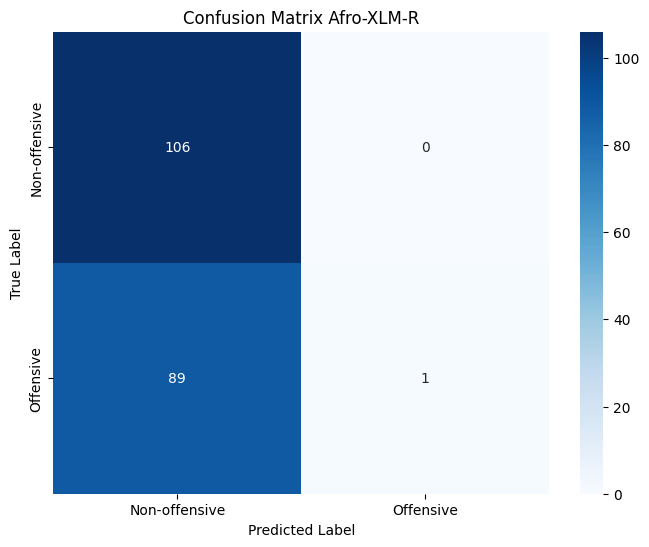

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Afro-XLM-R')
plt.show()